In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:
df = pd.read_csv("StudentsPerformance.csv")

print(df)


     gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none          72             72         

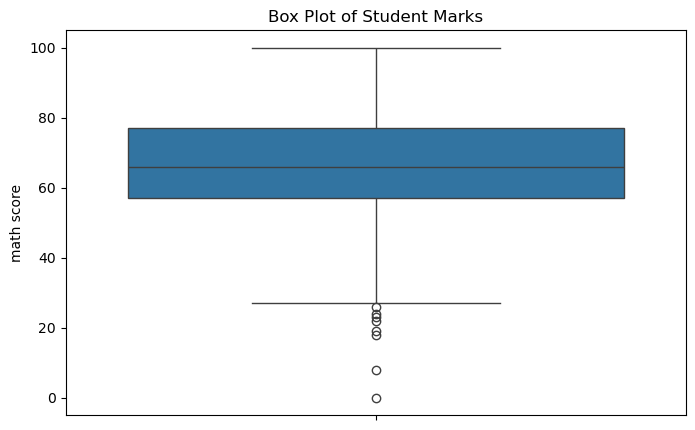

In [3]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df['math score'])

plt.title("Box Plot of Student Marks")
plt.ylabel("math score")

plt.show()


In [4]:
Q1 = df['math score'].quantile(0.25)
Q3 = df['math score'].quantile(0.75)

print("Q1 =", Q1)
print("Q3 =", Q3)


Q1 = 57.0
Q3 = 77.0


In [5]:
IQR = Q3 - Q1

print("IQR =", IQR)


IQR = 20.0


In [6]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit =", lower_limit)
print("Upper Limit =", upper_limit)


Lower Limit = 27.0
Upper Limit = 107.0


In [7]:
outliers_iqr = df[
    (df['math score'] < lower_limit) |
    (df['math score'] > upper_limit)
]

print("Outliers detected using IQR:")
print(outliers_iqr)


Outliers detected using IQR:
     gender race/ethnicity parental level of education         lunch  \
17   female        group B            some high school  free/reduced   
59   female        group C            some high school  free/reduced   
145  female        group C                some college  free/reduced   
338  female        group B            some high school  free/reduced   
466  female        group D          associate's degree  free/reduced   
787  female        group B                some college      standard   
842  female        group B                 high school  free/reduced   
980  female        group B                 high school  free/reduced   

    test preparation course  math score  reading score  writing score  
17                     none          18             32             28  
59                     none           0             17             10  
145                    none          22             39             33  
338                    none       

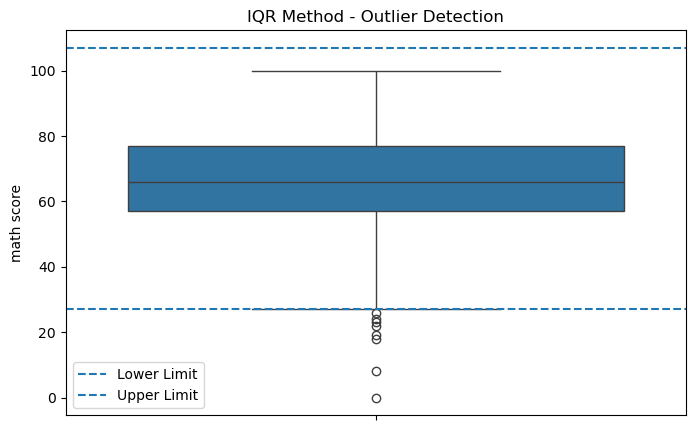

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df['math score'])

plt.axhline(lower_limit, linestyle='--', label='Lower Limit')
plt.axhline(upper_limit, linestyle='--', label='Upper Limit')

plt.title("IQR Method - Outlier Detection")
plt.legend()

plt.show()


In [9]:
df['Marks_IQR_Capped'] = df['math score'].clip(
    lower=lower_limit,
    upper=upper_limit
)

print(df[['math score', 'Marks_IQR_Capped']])


     math score  Marks_IQR_Capped
0            72                72
1            69                69
2            90                90
3            47                47
4            76                76
..          ...               ...
995          88                88
996          62                62
997          59                59
998          68                68
999          77                77

[1000 rows x 2 columns]


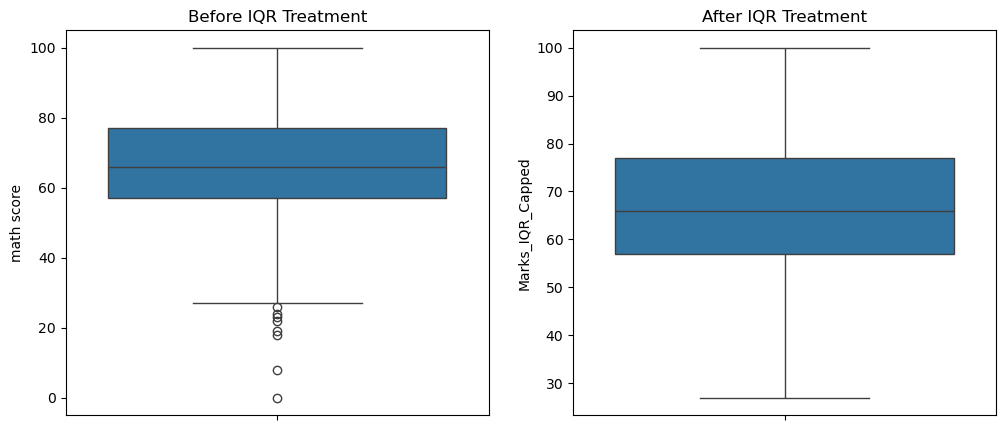

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['math score'], ax=axes[0])
axes[0].set_title("Before IQR Treatment")

sns.boxplot(y=df['Marks_IQR_Capped'], ax=axes[1])
axes[1].set_title("After IQR Treatment")

plt.show()


In [11]:
df['Z_score'] = stats.zscore(df['math score'])

print(df[['math score', 'Z_score']])


     math score   Z_score
0            72  0.390024
1            69  0.192076
2            90  1.577711
3            47 -1.259543
4            76  0.653954
..          ...       ...
995          88  1.445746
996          62 -0.269803
997          59 -0.467751
998          68  0.126093
999          77  0.719937

[1000 rows x 2 columns]


In [12]:
z_outliers = df[abs(df['Z_score']) > 3]

print("Outliers detected using Z-score:")
print(z_outliers)

df['Z_Outlier'] = abs(df['Z_score']) > 3

print(df[['math score', 'Z_score', 'Z_Outlier']])


Outliers detected using Z-score:
     gender race/ethnicity parental level of education         lunch  \
17   female        group B            some high school  free/reduced   
59   female        group C            some high school  free/reduced   
787  female        group B                some college      standard   
980  female        group B                 high school  free/reduced   

    test preparation course  math score  reading score  writing score  \
17                     none          18             32             28   
59                     none           0             17             10   
787                    none          19             38             32   
980                    none           8             24             23   

     Marks_IQR_Capped   Z_score  
17                 27 -3.173040  
59                 27 -4.360728  
787                27 -3.107058  
980                27 -3.832867  
     math score   Z_score  Z_Outlier
0            72  0.390024      Fa

In [13]:
mean = df['math score'].mean()
std = df['math score'].std()

lower_z_limit = mean - 3 * std
upper_z_limit = mean + 3 * std

print("Mean =", mean)
print("Standard Deviation =", std)
print("Lower Z-score limit =", lower_z_limit)
print("Upper Z-score limit =", upper_z_limit)

df['Marks_Z_Capped'] = df['math score'].clip(
    lower=lower_z_limit,
    upper=upper_z_limit
)

print("\nZ-score capped values:")
print(df[['math score', 'Marks_Z_Capped']])

Mean = 66.089
Standard Deviation = 15.163080096009468
Lower Z-score limit = 20.599759711971593
Upper Z-score limit = 111.57824028802841

Z-score capped values:
     math score  Marks_Z_Capped
0            72            72.0
1            69            69.0
2            90            90.0
3            47            47.0
4            76            76.0
..          ...             ...
995          88            88.0
996          62            62.0
997          59            59.0
998          68            68.0
999          77            77.0

[1000 rows x 2 columns]


In [14]:
print(df[['math score',
          'Marks_IQR_Capped',
          'Marks_Z_Capped']])

     math score  Marks_IQR_Capped  Marks_Z_Capped
0            72                72            72.0
1            69                69            69.0
2            90                90            90.0
3            47                47            47.0
4            76                76            76.0
..          ...               ...             ...
995          88                88            88.0
996          62                62            62.0
997          59                59            59.0
998          68                68            68.0
999          77                77            77.0

[1000 rows x 3 columns]


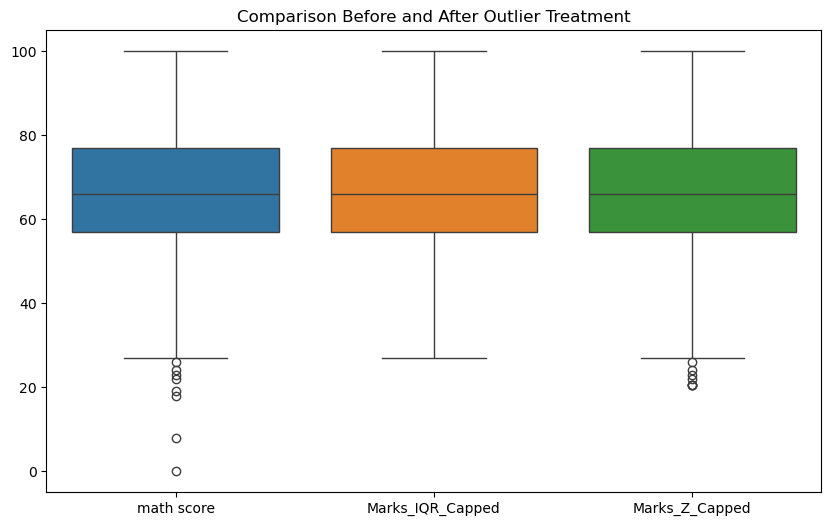

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[['math score',
             'Marks_IQR_Capped',
             'Marks_Z_Capped']]
)

plt.title("Comparison Before and After Outlier Treatment")
plt.show()